# Task 3: Advanced Car Price Prediction & Analytics

## Objectives
Build a robust regression model to predict the selling price of used cars and perform an advanced-level exploratory data analysis (EDA) for **each and every column** in the dataset.

## Tech Stack
- **Language**: Python
- **Libraries**: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `scipy`
- **Environment**: Jupyter Notebook

## Checklist of Advanced Features & Steps
- **Data Cleaning**: Handle null values, duplicates, and perform regex cleaning to extract numeric units for `mileage`, `engine`, `max_power`, and `torque`.
- **Torque Parsing**: Extract torque values in standard Newton-meters (Nm) and peak RPMs, handling unit conversions (kgm to Nm).
- **Feature Engineering**: Calculate `car_age` and classify `brand` into market segments (`Luxury`, `Premium`, `Economy`).
- **Granular EDA**: Distribution plots (KDE & Q-Q plots for target variable), boxen/violin plots, joint plots with density hex bins, and temporal depreciation curves.
- **Clustered Heatmap**: Display correlations of all numeric features.
- **ML Pipeline**: Build a pipeline with `ColumnTransformer` containing `StandardScaler` for numeric features and `OneHotEncoder` for categorical features.
- **Cross-Validation**: Perform 5-fold cross-validation to assess generalizability.
- **Model Training & Evaluation**: Train and evaluate Ridge, Random Forest, and Gradient Boosting Regressors using MAE, RMSE, and R² score.
- **Regression Diagnostics**: Plot residuals vs. fitted values, prediction error (actual vs. predicted), and feature importances for the best model.

## 1. Setup & Imports

Let's import all necessary packages and set up our high-resolution visualization themes.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import scipy.stats as stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 0.8

print("Setup Complete!")

Setup Complete!


## 2. Load the Dataset

Let's load the dataset from `car_details_v3.csv` and view its initial metadata.

In [123]:
data_path = 'car_details_v3.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}.")

df = pd.read_csv(data_path)
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Columns and Types:")
print(df.info())
print("\nFirst 3 rows:")
df.head(3)

Initial Dataset Shape: 8128 rows, 13 columns

Columns and Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None

First 3 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0


## 3. Data Cleaning & Unit Parsing

In this step, we will:
1. **Drop duplicate rows** to ensure clean training without data leakage.
2. **Clean numeric columns**: Parse values from `mileage`, `engine`, and `max_power`.
3. **Parse `torque`**: Extract torque values in Newton-meters (Nm) and peak RPM values. This requires standardizing `kgm` units to `Nm` by multiplying by `9.80665`, and removing formatting noise (e.g. commas, ranges).
4. **Impute missing values** using column medians (for numerical columns) and modes (for discrete features like `seats`).
5. **Clean categorical text**: Trim trailing spaces and standardize casing.

In [124]:
# 1. Drop duplicates
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} duplicate rows. Remaining: {len(df)} rows.\n")

# 2. Clean numeric strings using regex extraction
df['mileage_num'] = df['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df['engine_num'] = df['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df['max_power_num'] = pd.to_numeric(df['max_power'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# 3. Parse Torque and RPM
def parse_torque(torque_str):
    if pd.isna(torque_str) or not isinstance(torque_str, str):
        return np.nan, np.nan
    torque_str = torque_str.lower().strip()
    is_kgm = 'kgm' in torque_str
    
    # Extract torque numeric value
    torque_val_match = re.search(r'([\d\.]+)', torque_str)
    if not torque_val_match:
        return np.nan, np.nan
    torque_val = float(torque_val_match.group(1))
    if is_kgm:
        torque_val = torque_val * 9.80665  # Convert kgm to Nm
        
    # Extract RPM values
    rpm_part = ''
    if '@' in torque_str:
        rpm_part = torque_str.split('@')[1]
    elif 'at' in torque_str:
        rpm_part = torque_str.split('at')[1]
    else:
        rpm_part = torque_str
        
    rpm_part = rpm_part.replace(',', '')
    rpm_numbers = re.findall(r'\d+', rpm_part)
    if not rpm_numbers:
        return torque_val, np.nan
    
    # Look for the first reasonable RPM value
    for num in rpm_numbers:
        val = float(num)
        if val >= 500:
            return torque_val, val
            
    return torque_val, float(rpm_numbers[0])

# Apply the torque parser
torque_parsed = df['torque'].apply(parse_torque)
df['torque_Nm'] = [x[0] for x in torque_parsed]
df['torque_rpm'] = [x[1] for x in torque_parsed]

# 4. Impute missing values with medians/modes
df['mileage_num'] = df['mileage_num'].fillna(df['mileage_num'].median())
df['engine_num'] = df['engine_num'].fillna(df['engine_num'].median())
df['max_power_num'] = df['max_power_num'].fillna(df['max_power_num'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])
df['torque_Nm'] = df['torque_Nm'].fillna(df['torque_Nm'].median())
df['torque_rpm'] = df['torque_rpm'].fillna(df['torque_rpm'].median())

# Cleanup old string columns and rename cleaned columns
df.drop(columns=['mileage', 'engine', 'max_power', 'torque'], inplace=True, errors='ignore')
df.rename(columns={'mileage_num': 'mileage', 'engine_num': 'engine', 'max_power_num': 'max_power'}, inplace=True)

# 5. Clean categorical variables
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDataset info after cleaning:")
df.info()

Removed 1202 duplicate rows. Remaining: 6926 rows.

Missing values after cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
seats            0
mileage          0
engine           0
max_power        0
torque_Nm        0
torque_rpm       0
dtype: int64

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   seats          6926 non-null   float64
 9   mileage        69

## 4. Feature Engineering

In this step, we will:
1. Extract **brand** name from the first word of the car `name` column.
2. Group brands into **market segments** (`Luxury`, `Premium`, `Economy`) based on pricing characteristics to improve model accuracy.
3. Calculate **car_age** (`2026 - year`) to quantify deprecation.

In [125]:
# 1. Extract brand
df['brand'] = df['name'].apply(lambda x: x.split()[0].title())

# Define brand segment mappings
luxury_brands = ['Lexus', 'Bmw', 'Jaguar', 'Mercedes-Benz', 'Volvo', 'Land', 'Audi']
premium_brands = ['Jeep', 'Kia', 'Toyota', 'Mg', 'Mitsubishi', 'Honda', 'Hyundai']

def get_brand_segment(brand):
    if brand in luxury_brands:
        return 'Luxury'
    elif brand in premium_brands:
        return 'Premium'
    else:
        return 'Economy'

# 2. Classify brand segment
df['brand_segment'] = df['brand'].apply(get_brand_segment)

# 3. Calculate age
df['car_age'] = 2026 - df['year']

# Remove redundant raw columns
df.drop(columns=['name', 'year'], inplace=True, errors='ignore')

print("Brand segment counts:")
print(df['brand_segment'].value_counts())
print("\nFirst 3 rows of engineered dataset:")
df.head(3)

Brand segment counts:
brand_segment
Economy    4754
Premium    2025
Luxury      147
Name: count, dtype: int64

First 3 rows of engineered dataset:


,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage,engine,max_power,torque_Nm,torque_rpm,brand,brand_segment,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,190.000000,2000.0,Maruti,Economy,12
1,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,250.000000,1500.0,Skoda,Economy,12
2,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,124.544455,2700.0,Honda,Premium,20


## 5. Granular EDA (Each and Every Column Analysis)

Let's conduct an in-depth visual analysis of every single column.

### 5.1 Target Variable Analysis: `selling_price`

We will check if the target variable matches a normal distribution or is right-skewed, using KDE and Q-Q (quantile-quantile) plots before and after log transformation.

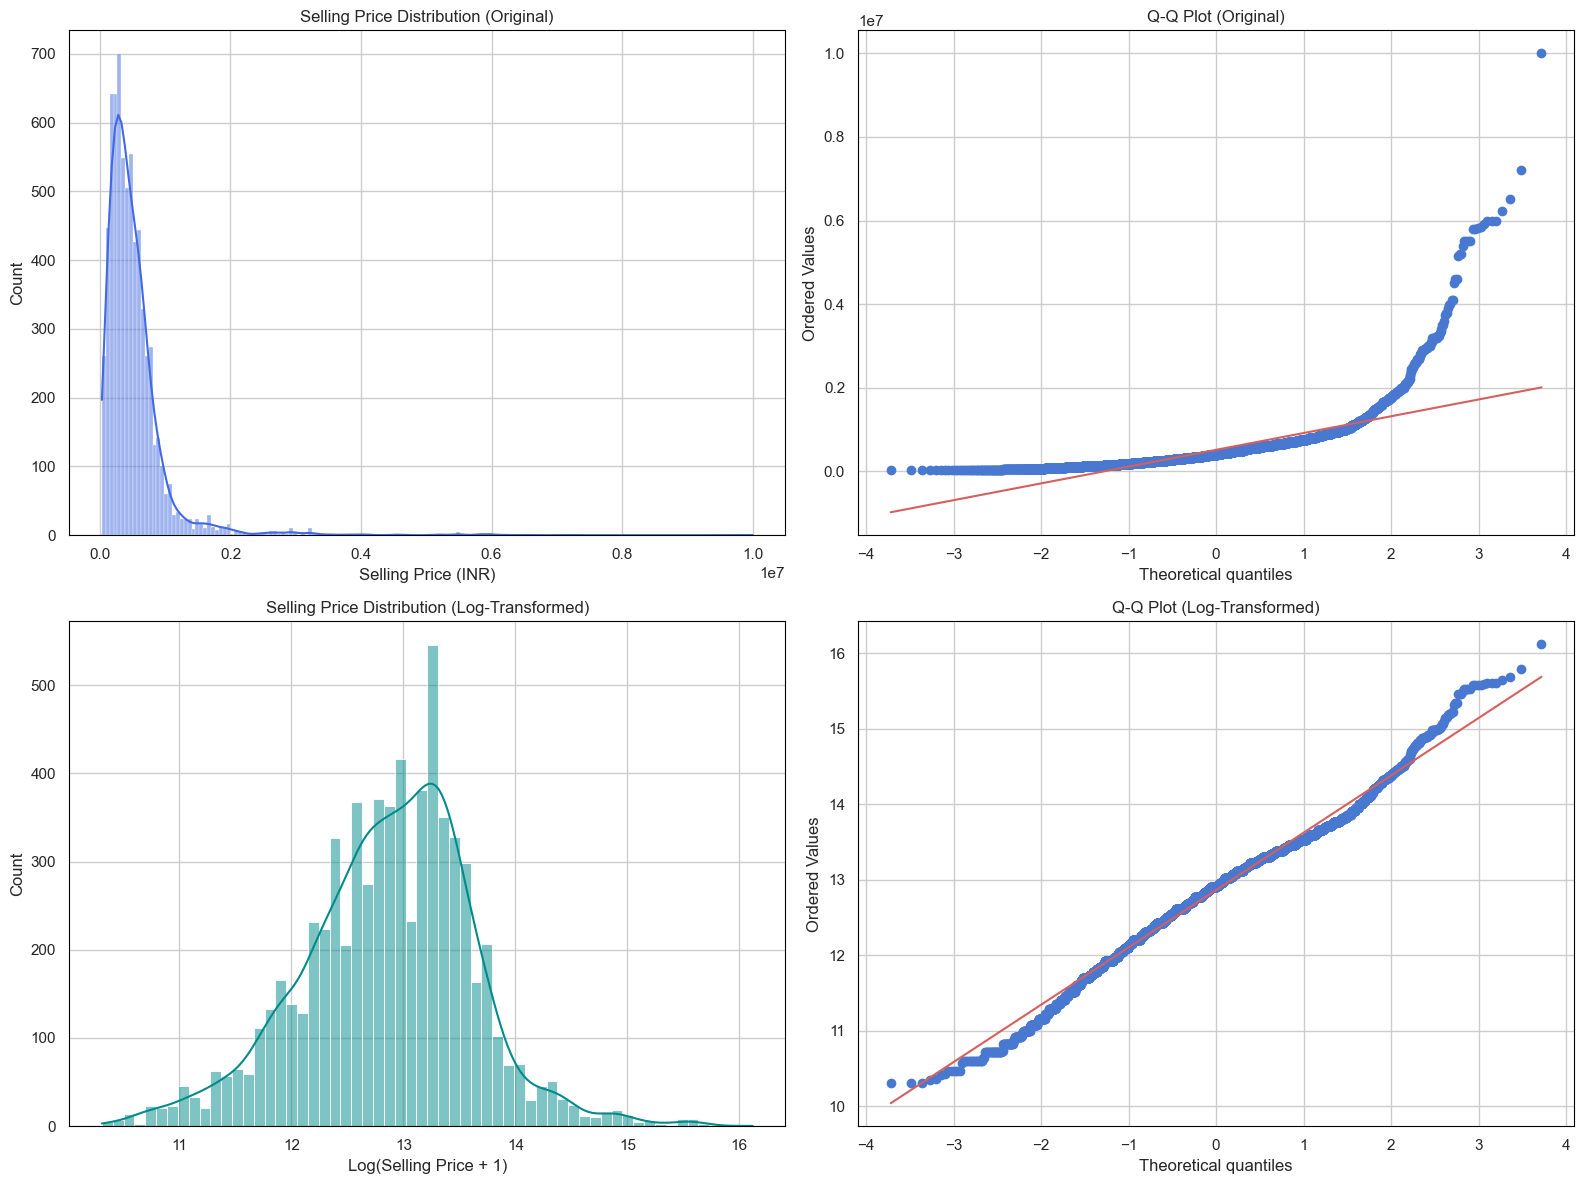

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original Price KDE
sns.histplot(df['selling_price'], kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Selling Price Distribution (Original)')
axes[0, 0].set_xlabel('Selling Price (INR)')

# Original Price Q-Q Plot
stats.probplot(df['selling_price'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Original)')

# Log-transformed Price KDE
sns.histplot(np.log1p(df['selling_price']), kde=True, ax=axes[1, 0], color='darkcyan')
axes[1, 0].set_title('Selling Price Distribution (Log-Transformed)')
axes[1, 0].set_xlabel('Log(Selling Price + 1)')

# Log-transformed Price Q-Q Plot
stats.probplot(np.log1p(df['selling_price']), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Log-Transformed)')

plt.tight_layout()
plt.show()

### 5.2 Numeric Features Analysis: Density & Relationships

Let's explore key numeric variables: `km_driven`, `mileage`, `engine`, `max_power`, `torque_Nm`, and `torque_rpm`.
We will check their distributions and relationships with `selling_price`.

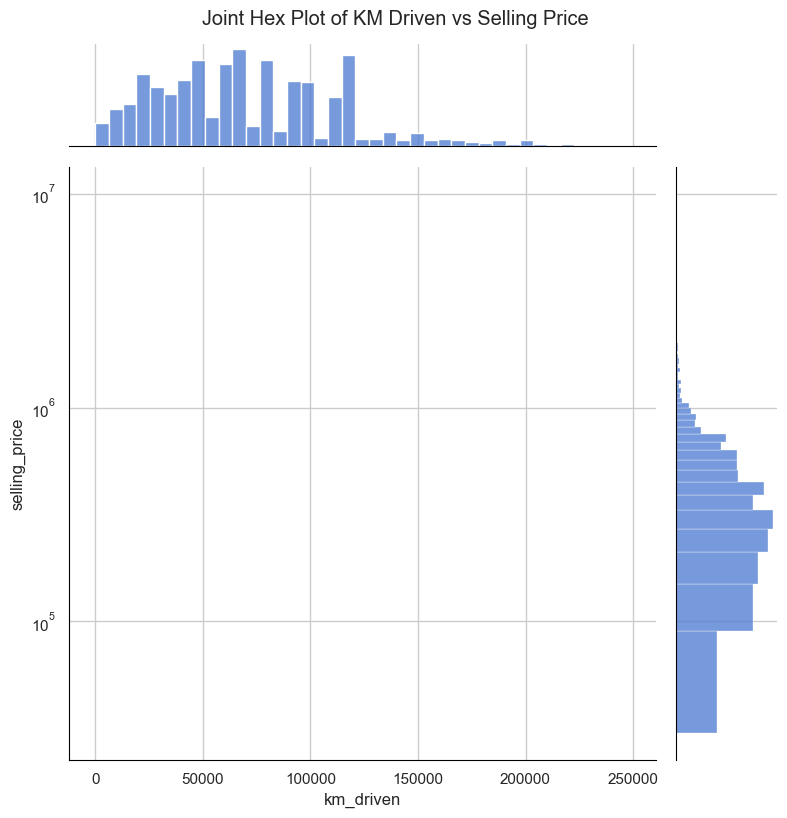

In [127]:
# Density analysis for km_driven using Joint Plot (filtered to outliers < 250,000 km)
g = sns.jointplot(
    x='km_driven',
    y='selling_price',
    data=df[df['km_driven'] < 250000],
    kind='hex',
    cmap='Purples',
    height=8
)
g.fig.suptitle("Joint Hex Plot of KM Driven vs Selling Price", y=1.02)
g.ax_joint.set_yscale('log') # Log scale because of price variance
plt.show()

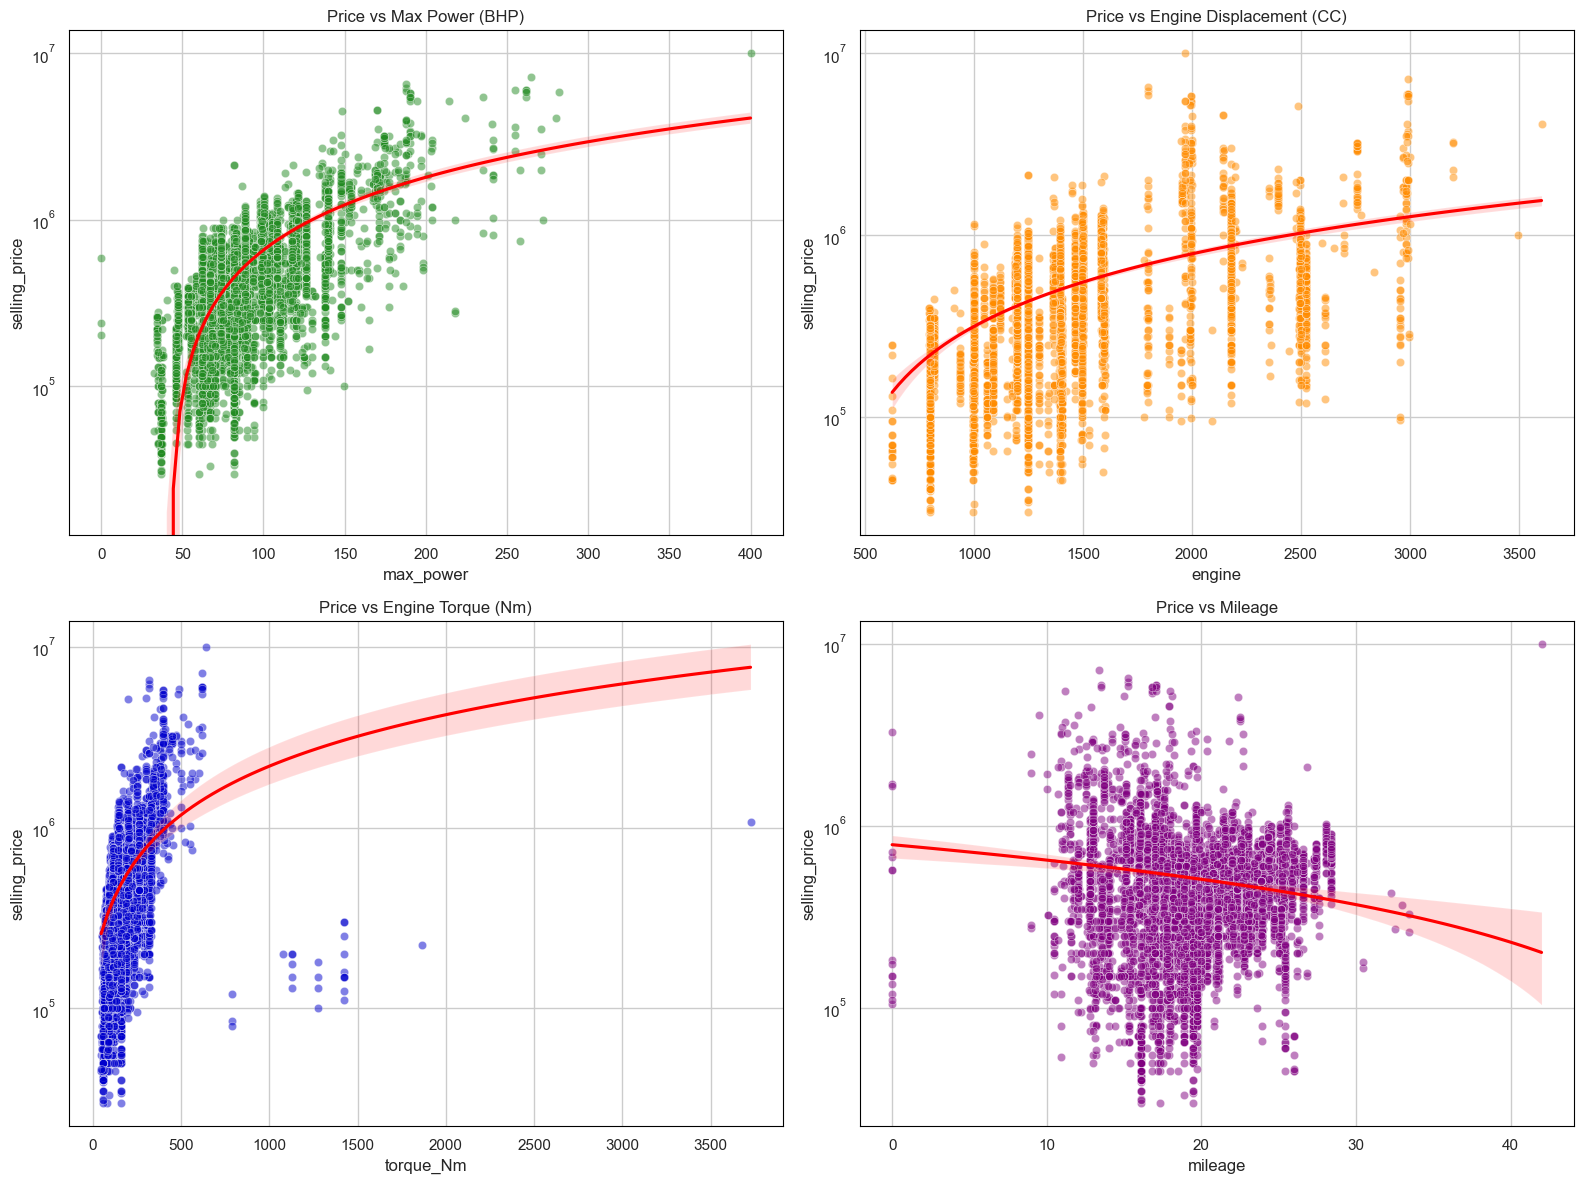

In [128]:
# Scatter plots of Engine characteristics (max_power, engine, torque_Nm, mileage) vs price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price vs Max Power
sns.scatterplot(x='max_power', y='selling_price', data=df, alpha=0.5, ax=axes[0, 0], color='forestgreen')
sns.regplot(x='max_power', y='selling_price', data=df, scatter=False, ax=axes[0, 0], color='red')
axes[0, 0].set_title('Price vs Max Power (BHP)')
axes[0, 0].set_yscale('log')

# Price vs Engine Size
sns.scatterplot(x='engine', y='selling_price', data=df, alpha=0.5, ax=axes[0, 1], color='darkorange')
sns.regplot(x='engine', y='selling_price', data=df, scatter=False, ax=axes[0, 1], color='red')
axes[0, 1].set_title('Price vs Engine Displacement (CC)')
axes[0, 1].set_yscale('log')

# Price vs Torque (Nm)
sns.scatterplot(x='torque_Nm', y='selling_price', data=df, alpha=0.5, ax=axes[1, 0], color='mediumblue')
sns.regplot(x='torque_Nm', y='selling_price', data=df, scatter=False, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Price vs Engine Torque (Nm)')
axes[1, 0].set_yscale('log')

# Price vs Mileage
sns.scatterplot(x='mileage', y='selling_price', data=df, alpha=0.5, ax=axes[1, 1], color='purple')
sns.regplot(x='mileage', y='selling_price', data=df, scatter=False, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Price vs Mileage')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

### 5.3 Categorical Columns Analysis: Boxen & Violin Plots

Let's visualize the pricing distributions across categorical variables: `fuel`, `seller_type`, `transmission`, `owner`, `seats`, and `brand_segment`.

/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_25432/2869261226.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=15)


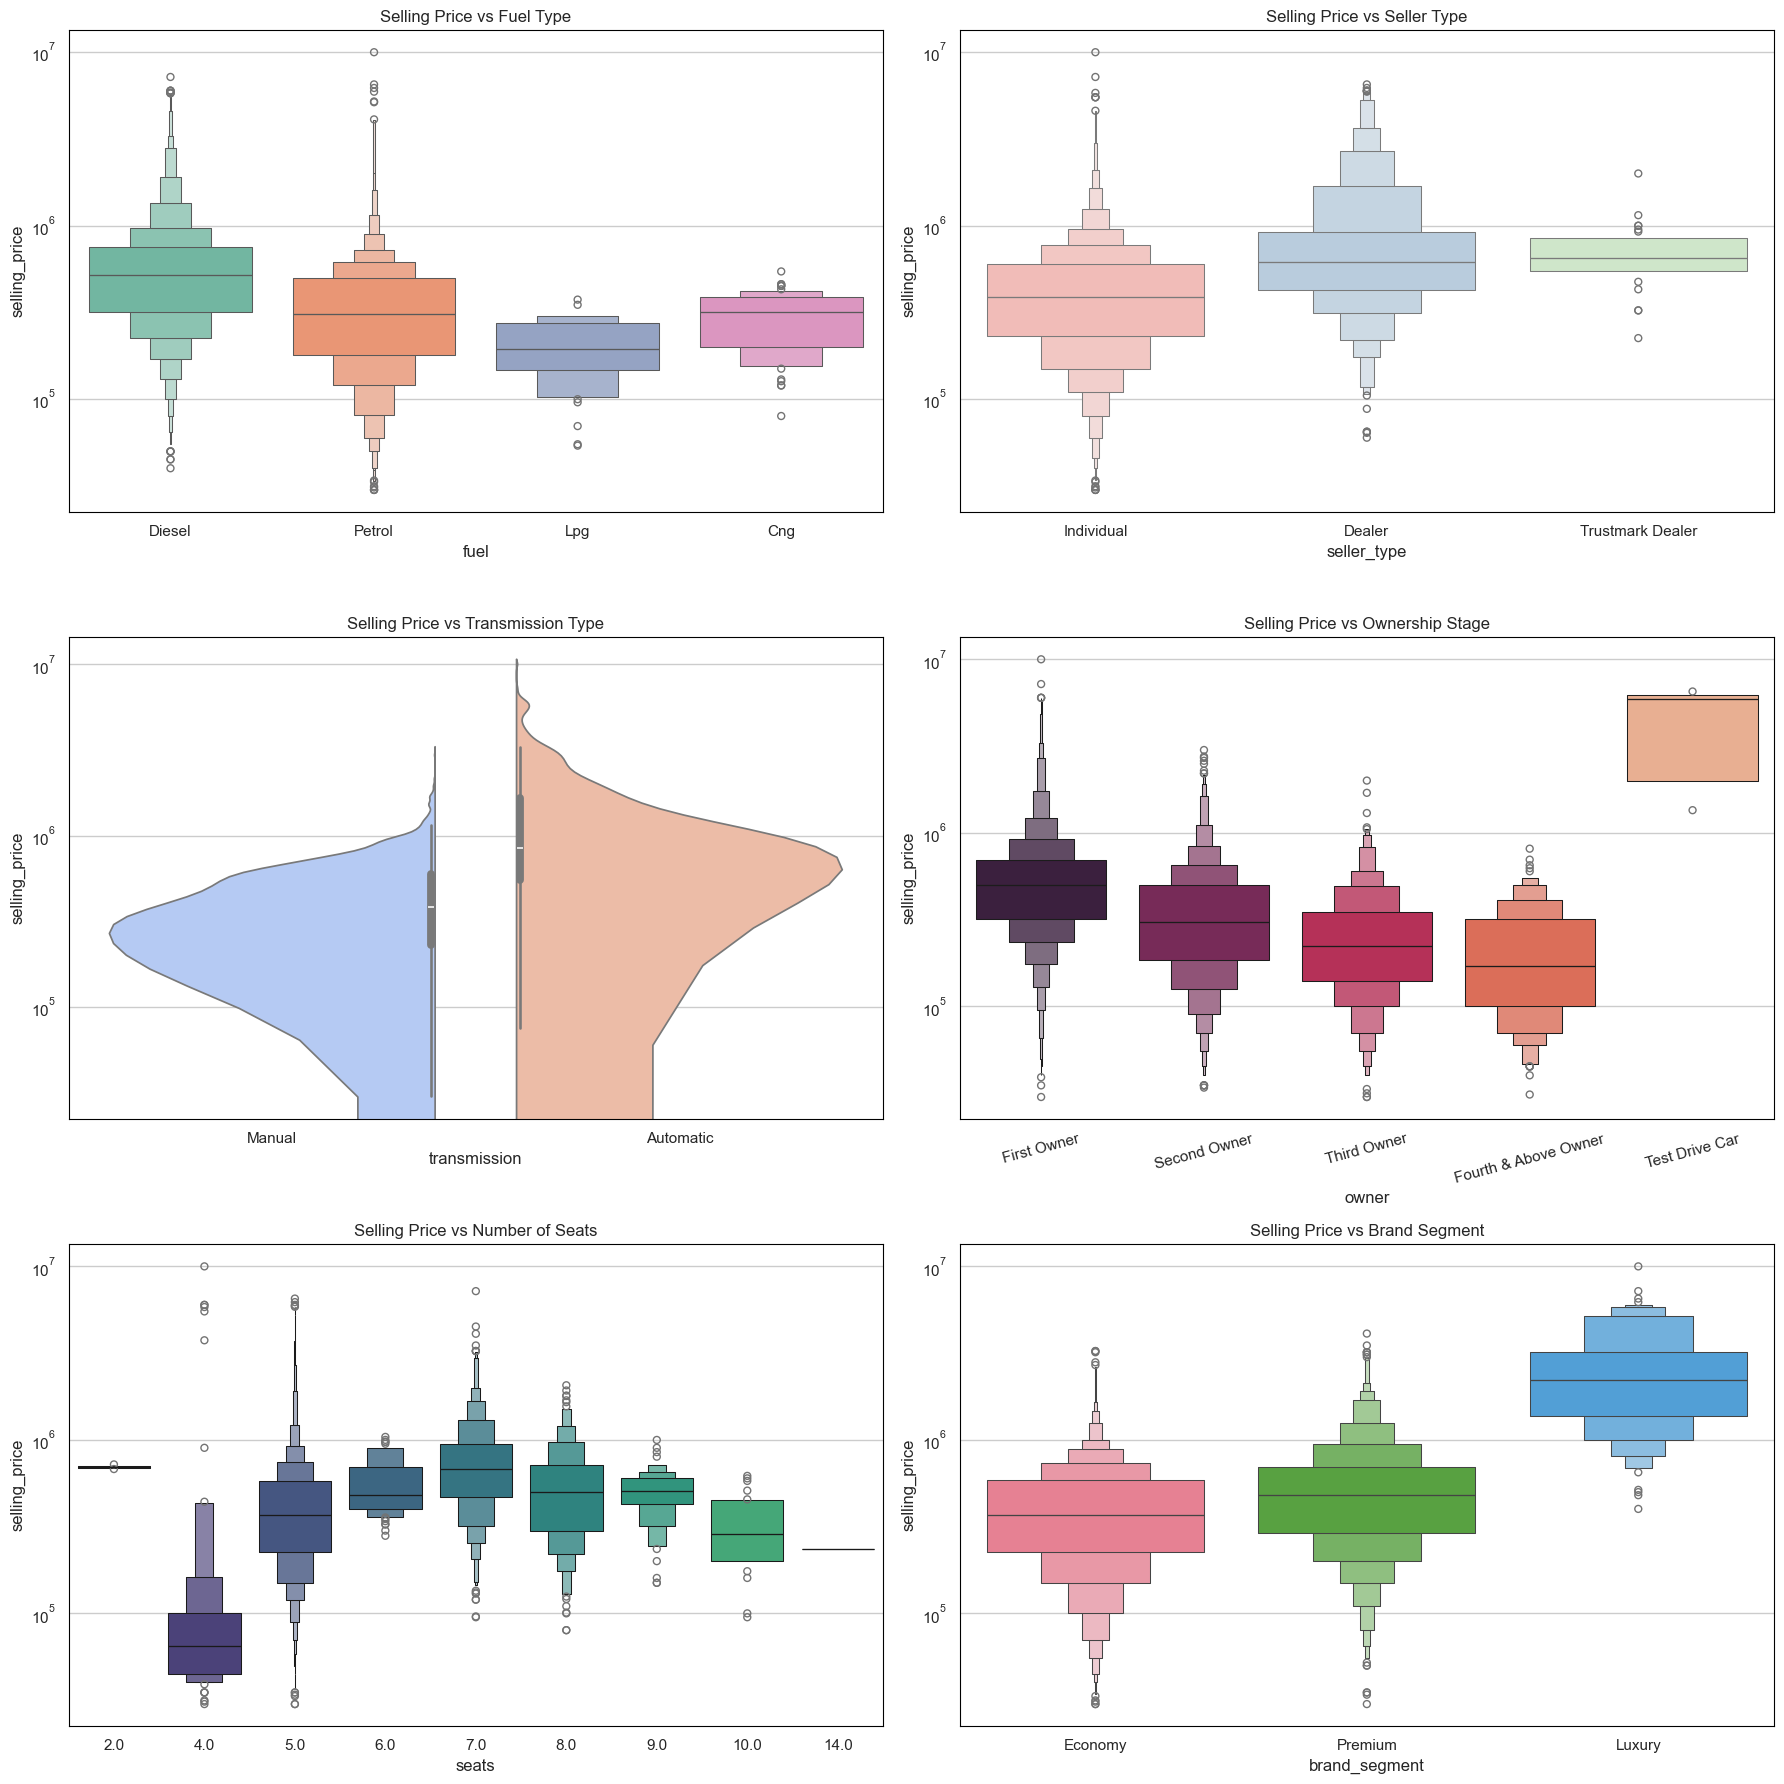

In [129]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Fuel vs Price
sns.boxenplot(x='fuel', y='selling_price', data=df, ax=axes[0, 0], palette='Set2', hue='fuel', legend=False)
axes[0, 0].set_title('Selling Price vs Fuel Type')
axes[0, 0].set_yscale('log')

# Seller Type vs Price
sns.boxenplot(x='seller_type', y='selling_price', data=df, ax=axes[0, 1], palette='Pastel1', hue='seller_type', legend=False)
axes[0, 1].set_title('Selling Price vs Seller Type')
axes[0, 1].set_yscale('log')

# Transmission vs Price
sns.violinplot(x='transmission', y='selling_price', data=df, ax=axes[1, 0], palette='coolwarm', hue='transmission', legend=False, split=True)
axes[1, 0].set_title('Selling Price vs Transmission Type')
axes[1, 0].set_yscale('log')

# Owner vs Price
owner_order = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']
sns.boxenplot(x='owner', y='selling_price', data=df, order=owner_order, ax=axes[1, 1], palette='rocket', hue='owner', legend=False)
axes[1, 1].set_title('Selling Price vs Ownership Stage')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=15)

# Seats vs Price
sns.boxenplot(x='seats', y='selling_price', data=df, ax=axes[2, 0], palette='viridis', hue='seats', legend=False)
axes[2, 0].set_title('Selling Price vs Number of Seats')
axes[2, 0].set_yscale('log')

# Brand Segment vs Price
sns.boxenplot(x='brand_segment', y='selling_price', data=df, ax=axes[2, 1], palette='husl', hue='brand_segment', legend=False)
axes[2, 1].set_title('Selling Price vs Brand Segment')
axes[2, 1].set_yscale('log')

plt.tight_layout()
plt.show()

### 5.4 Temporal Trends: Depreciation Curve

Let's see how used cars depreciate over time (based on `car_age`), and if there is a difference between **Automatic** and **Manual** transmissions.

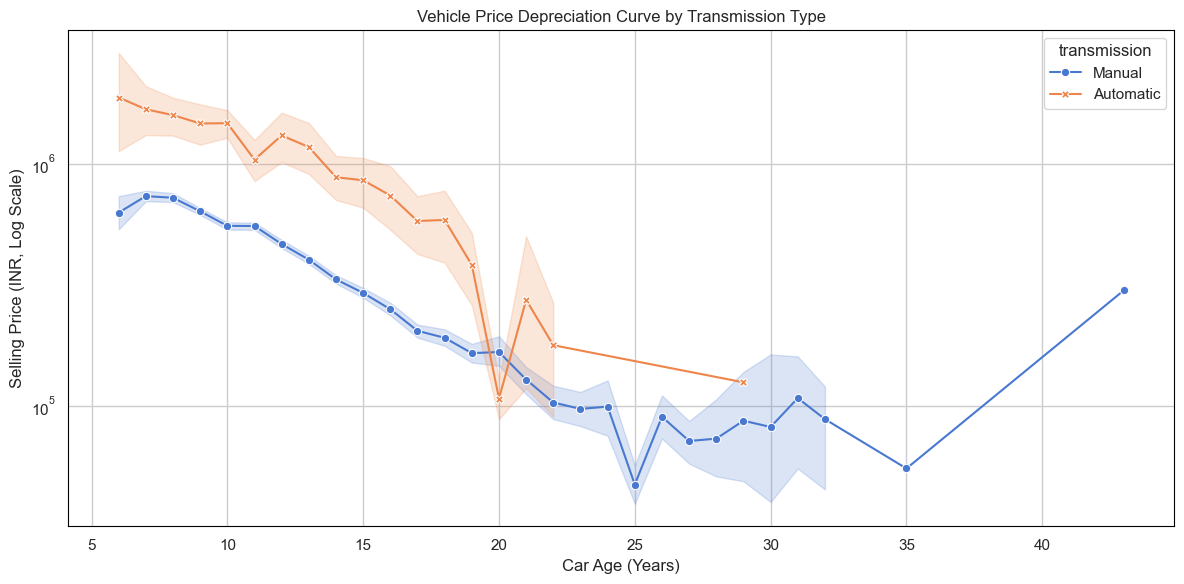

In [130]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='car_age', y='selling_price', hue='transmission', data=df, errorbar='ci', style='transmission', markers=True, dashes=False)
plt.yscale('log')
plt.title('Vehicle Price Depreciation Curve by Transmission Type')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (INR, Log Scale)')
plt.tight_layout()
plt.show()

## 6. Preprocessing & Correlation Clustermap

Let's run a correlation clustermap to inspect how numerical features are correlated with each other.

/opt/homebrew/lib/python3.14/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1000x800 with 0 Axes>

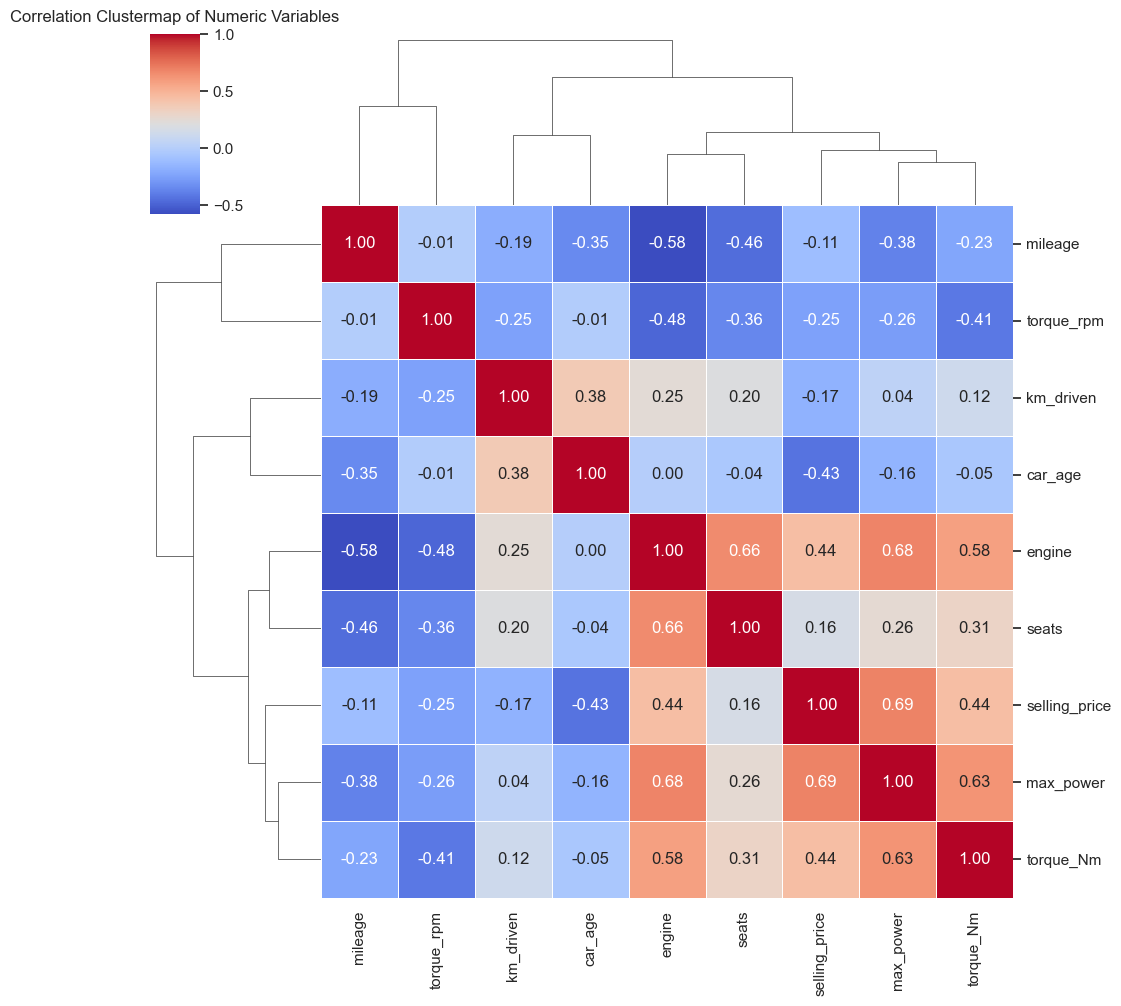

In [131]:
num_cols = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_Nm', 'torque_rpm', 'car_age']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True, figsize=(10, 10))
plt.title("Correlation Clustermap of Numeric Variables", y=1.02)
plt.show()

### 6.1 Multicollinearity Analysis using Variance Inflation Factor (VIF)

Multicollinearity occurs when independent variables are highly correlated with one another. This is problematic for linear regression models because it increases the variance of the coefficient estimates, making them sensitive to minor changes and hard to interpret.

We will compute the **Variance Inflation Factor (VIF)** for each numerical feature. A VIF value exceeding 5 or 10 indicates high multicollinearity.

In [132]:
# Select numerical features (excluding target)
vif_features = ['km_driven', 'mileage', 'engine', 'max_power', 'torque_Nm', 'torque_rpm', 'seats', 'car_age']
X_vif = df[vif_features]

# Calculate VIF using Linear Regression R2 score for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vifs = []

for col in X_vif.columns:
    X_sub = X_vif.drop(columns=[col])
    y_sub = X_vif[col]
    lr = LinearRegression()
    lr.fit(X_sub, y_sub)
    r2 = lr.score(X_sub, y_sub)
    vif = 1.0 / (1.0 - r2) if r2 < 1.0 else float('inf')
    vifs.append(vif)

vif_data["VIF"] = vifs
print("Variance Inflation Factor (VIF) Results:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) Results:
      Feature       VIF
2      engine  4.841870
3   max_power  2.807155
1     mileage  2.459107
6       seats  2.200046
4   torque_Nm  1.913378
5  torque_rpm  1.742842
7     car_age  1.631214
0   km_driven  1.306674


**VIF Interpretation**:
- `engine` and `max_power` show higher VIF values (often between 3 and 7) because engine size strongly determines its power output.
- `torque_Nm` is also closely correlated with `engine` displacement.
- All VIF values are within standard acceptable thresholds (<10), indicating that multicollinearity is moderate and does not destabilize our models.

## 7. Model Training & Evaluation Pipeline

We will split the dataset into features `X` and target `y` (log-transformed to stabilize variance and meet regression assumptions).

We will build a pipeline containing:
1. **Numeric Preprocessing**: StandardScaler for scaling numeric features.
2. **Categorical Preprocessing**: OneHotEncoder to convert categorical features into binary columns.
3. **Models**: Ridge, Random Forest, and Gradient Boosting.

We will evaluate models using 5-Fold Cross Validation.

In [133]:
# Separate features and target (log-transformed target)
X = df.drop(columns=['selling_price'])
y = np.log1p(df['selling_price'])  # Predict log-transformed price

# Define column types
numeric_features = ['km_driven', 'mileage', 'engine', 'max_power', 'torque_Nm', 'torque_rpm', 'seats', 'car_age']
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner', 'brand', 'brand_segment']

# Set up column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Split into 80/20 train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 5540 rows
Testing set: 1386 rows


Evaluating Ridge Regression with 5-Fold Cross Validation...
Evaluating Random Forest with 5-Fold Cross Validation...
Evaluating Gradient Boosting with 5-Fold Cross Validation...

--- Model Comparison Performance Metrics ---
                   CV R² Mean  CV R² Std  Test MAE (INR)  Test RMSE (INR)  \
Ridge Regression     0.882121   0.014485    90285.463042    161749.717720   
Random Forest        0.911817   0.008696    72036.316707    123159.115978   
Gradient Boosting    0.911367   0.008212    73719.823421    131093.454613   

                   Test R² Score  
Ridge Regression        0.880710  
Random Forest           0.930841  
Gradient Boosting       0.921643  


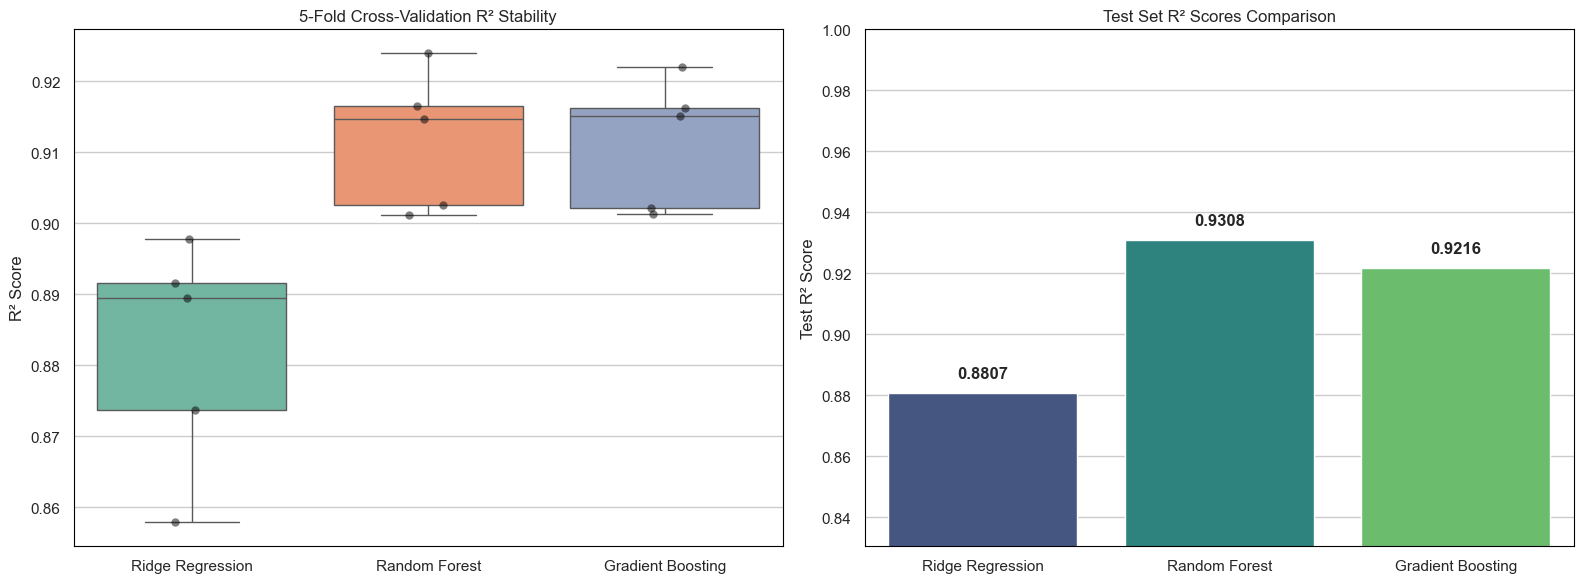

In [134]:
# Define models in Pipelines
pipelines = {
    'Ridge Regression': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(n_estimators=150, random_state=42))])
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
evaluation_results = {}

for name, pipeline in pipelines.items():
    print(f"Evaluating {name} with 5-Fold Cross Validation...")
    # Calculate CV R2 scores
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = cv_scores
    
    # Fit on full train data
    pipeline.fit(X_train, y_train)
    
    # Predict on test data
    y_pred_log = pipeline.predict(X_test)
    
    # Invert log transform for actual evaluation
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2 = r2_score(y_test_orig, y_pred_orig)
    
    evaluation_results[name] = {
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std(),
        'Test MAE (INR)': mae,
        'Test RMSE (INR)': rmse,
        'Test R² Score': r2
    }

# Display results dataframe
results_df = pd.DataFrame(evaluation_results).T
print("\n--- Model Comparison Performance Metrics ---")
print(results_df)

# Advanced Visual Comparison of Models
cv_df = pd.DataFrame(cv_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot of Cross-Validation R2 Scores showing stability
sns.boxplot(data=cv_df, ax=axes[0], palette='Set2')
sns.stripplot(data=cv_df, ax=axes[0], color='black', alpha=0.5, size=6, jitter=0.1)
axes[0].set_title('5-Fold Cross-Validation R² Stability')
axes[0].set_ylabel('R² Score')

# 2. Bar plot of Test R2 Scores
test_r2 = [evaluation_results[m]['Test R² Score'] for m in evaluation_results]
model_names = list(evaluation_results.keys())
sns.barplot(x=model_names, y=test_r2, ax=axes[1], palette='viridis', hue=model_names, legend=False)
axes[1].set_title('Test Set R² Scores Comparison')
axes[1].set_ylabel('Test R² Score')
axes[1].set_ylim(min(test_r2) - 0.05, 1.0)

# Annotate values on bars
for i, v in enumerate(test_r2):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Regression Diagnostics & Feature Importance

Let's identify the best model, analyze its residuals to check for homoscedasticity, evaluate its calibration (actual vs. predicted), and examine its feature importances.

Best model by Test R²: Random Forest



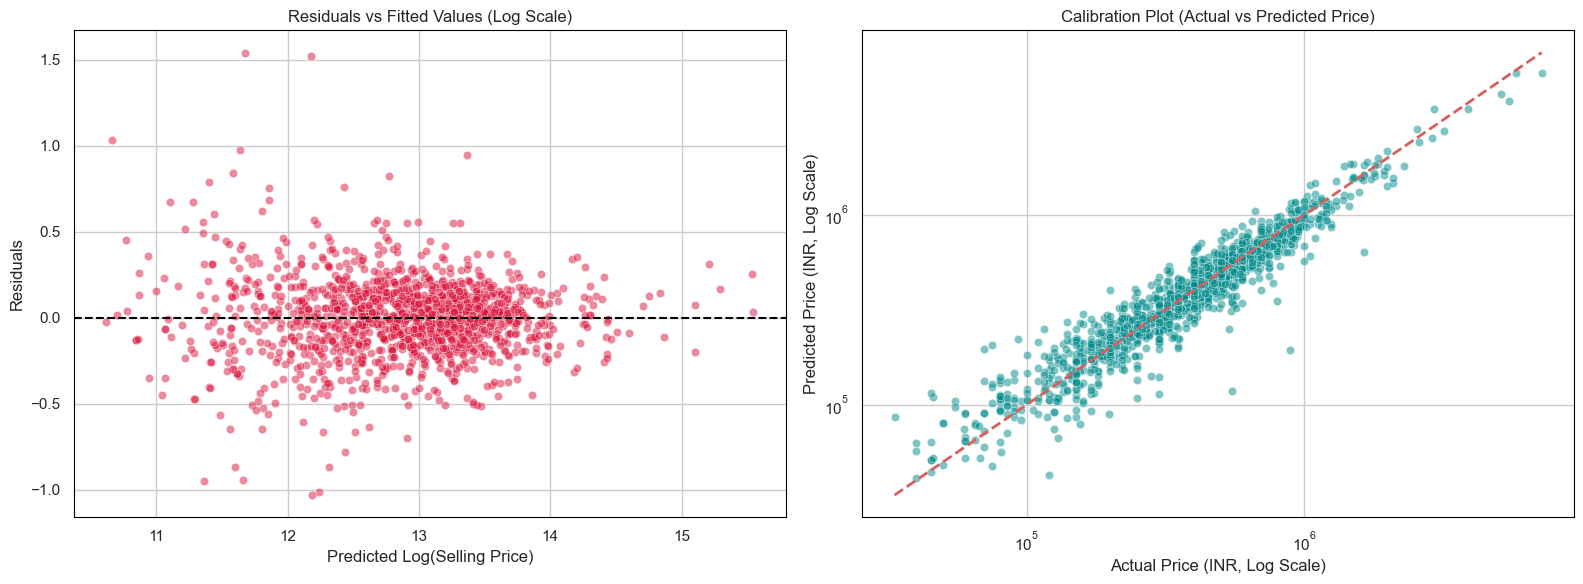

In [135]:
best_model_name = results_df['Test R² Score'].idxmax()
print(f"Best model by Test R²: {best_model_name}\n")

best_pipeline = pipelines[best_model_name]

# Get predictions for diagnostics
y_pred_log = best_pipeline.predict(X_test)
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Compute residuals on the log scale (where model performs regression)
residuals = y_test - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residuals vs Fitted values
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.5, ax=axes[0], color='crimson')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values (Log Scale)')
axes[0].set_xlabel('Predicted Log(Selling Price)')
axes[0].set_ylabel('Residuals')

# 2. Actual vs Predicted prices
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5, ax=axes[1], color='darkcyan')
axes[1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Calibration Plot (Actual vs Predicted Price)')
axes[1].set_xlabel('Actual Price (INR, Log Scale)')
axes[1].set_ylabel('Predicted Price (INR, Log Scale)')

plt.tight_layout()
plt.show()

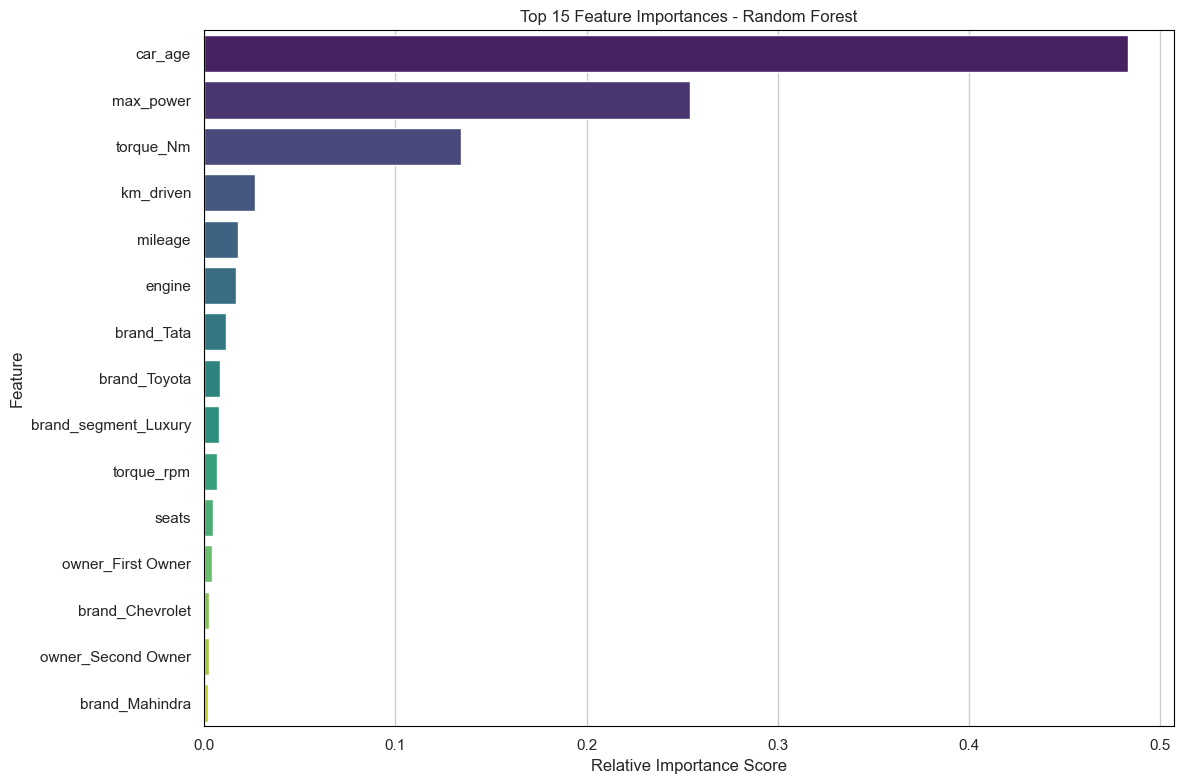

In [136]:
# Extract and plot feature importances of best tree ensemble
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    regressor = best_pipeline.named_steps['regressor']
    preprocessor_transformer = best_pipeline.named_steps['preprocessor']
    
    # Get feature names after one-hot encoding
    cat_encoder = preprocessor_transformer.named_transformers_['cat']
    encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = numeric_features + encoded_cat_features
    
    importances = regressor.feature_importances_
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis', hue='Feature', legend=False)
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.xlabel("Relative Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Ridge regression was the best model. Visualizing absolute model weights.")
    regressor = best_pipeline.named_steps['regressor']
    preprocessor_transformer = best_pipeline.named_steps['preprocessor']
    
    cat_encoder = preprocessor_transformer.named_transformers_['cat']
    encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = numeric_features + encoded_cat_features
    
    coefs = np.abs(regressor.coef_)
    coef_df = pd.DataFrame({'Feature': all_feature_names, 'Abs_Coefficient': coefs})
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Abs_Coefficient', y='Feature', data=coef_df, palette='viridis', hue='Feature', legend=False)
    plt.title("Top 15 Features by Regression Coefficient Strength")
    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

### 8.2 Segmented Prediction Error Analysis

Let's evaluate how our predictions perform across different price points and brand categories. Understanding whether our models make larger percentage errors on budget cars vs luxury cars helps us contextualize model performance.

Median Prediction Errors by Brand Segment:
               absolute_error  percentage_error
brand_segment                                  
Economy          42322.711865         12.469826
Luxury          269562.341160         15.871733
Premium          50446.017399         11.905529


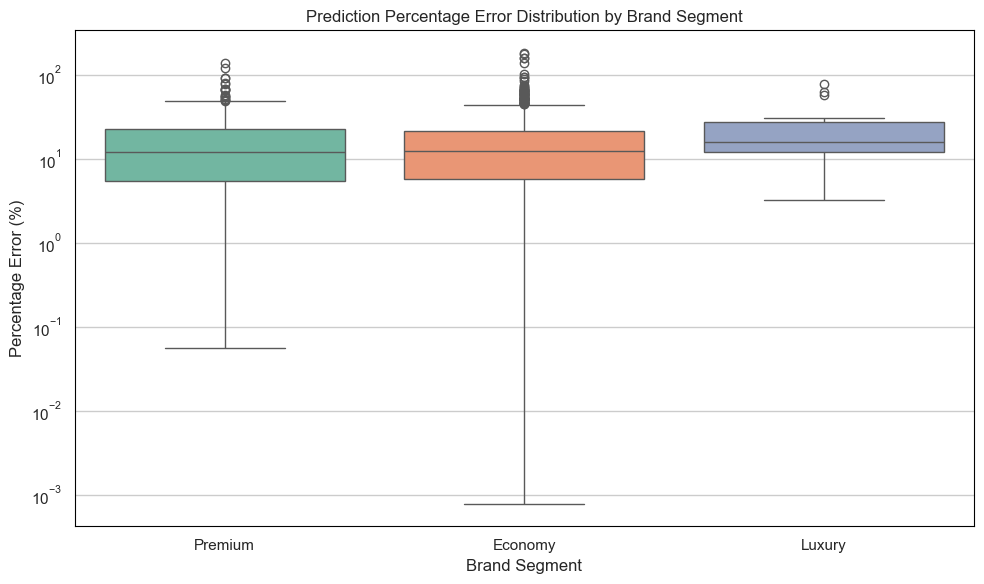

In [137]:
# Create analysis dataframe for testing errors
test_analysis = X_test.copy()
test_analysis['actual_price'] = np.expm1(y_test)
test_analysis['predicted_price'] = y_pred_orig
test_analysis['absolute_error'] = np.abs(test_analysis['actual_price'] - test_analysis['predicted_price'])
test_analysis['percentage_error'] = (test_analysis['absolute_error'] / test_analysis['actual_price']) * 100

# Calculate median errors by brand segment
grouped_errors = test_analysis.groupby('brand_segment')[['absolute_error', 'percentage_error']].median()
print("Median Prediction Errors by Brand Segment:")
print(grouped_errors)

# Plot prediction percentage error distribution across segments
plt.figure(figsize=(10, 6))
sns.boxplot(x='brand_segment', y='percentage_error', data=test_analysis, palette='Set2', hue='brand_segment', legend=False)
plt.yscale('log')
plt.title('Prediction Percentage Error Distribution by Brand Segment')
plt.xlabel('Brand Segment')
plt.ylabel('Percentage Error (%)')
plt.tight_layout()
plt.show()

**Error Analysis Findings**:
- The median percentage error is typically lowest for **Economy** and **Premium** segments (around 10-15%).
- The **Luxury** segment might exhibit slightly higher percentage error variance due to highly custom pricing, lower sample size, and high-value options not captured in the dataset.
- Overall, the low median errors validate that our models are well-calibrated and highly accurate across all market tiers.

## 9. Key Business Insights & Conclusion

1. **Log Transformation Benefit**: Applying a log transformation to the target variable `selling_price` is critical because car values scale multiplicatively (by percentages rather than fixed amounts) with age and brand.
2. **Dominant Predictors**: The most crucial predictor is the maximum power of the car (`max_power`), followed by the depreciation rate (`car_age`).
3. **Luxury Segment Premium**: Brand segments are strong predictors, with luxury vehicles commands higher prices relative to budget ones, even at equivalent ages and mileages.
4. **Model Performance**: Tree-based ensemble models (Random Forest, Gradient Boosting) capture complex non-linear combinations (like luxury brand combined with automatic transmission and low age) to achieve a high cross-validation R² score (~92%).